# Euclid Q1 hands-on: AGN selection on a color SOM

**AAS workshop:** *Euclid Data in the Cloud - Access, Analysis, and Science Opportunities* (90 min)

This 30-minute hands-on uses a pre-trained color SOM and a pre-projected EDF-N AGN catalog so
we can focus on the **cloud-access** half of the workshop title. The two tasks are:

1. **Task 1** - Pick one AGN selection method and visualize where it sits on the color manifold,
   relative to the union of all methods.
2. **Task 2** - Pick an individual AGN candidate, project it, and verify it against three
   independent **live cloud reads** against IRSA: its 1D Q1 SIR spectrum (direct S3 FITS read),
   its multi-band MER imaging (IBE server-side cutout), and its SPE H$\alpha$ line measurement
   (live TAP query). None of those data products are pre-cached for you.

**The cloud point.** Everything in Task 2 is fetched at workshop time from
`s3://nasa-irsa-euclid-q1/...` or `https://irsa.ipac.caltech.edu/...`. No downloads happened
in advance and none happen to disk now. Running this on Fornax it's region-local and
instant; from a laptop it works too over the public HTTPS/anonymous-S3 endpoints. The same
code scales unchanged to the full Q1 release and onward to DR1.

**The pre-built bits.** Only two things are pre-built for you, both to save ~2 minutes:
the trained SOM weights (`workshop_som.pkl`) and the EDF-N AGN catalog with each source's
best-matching unit (BMU) attached (`workshop_agn_edfn.fits`). Both are derived from queries
against the same cloud-hosted Q1 catalogs you'll touch live in Task 2.

**Scope.** EDF-N AGN candidates from Euclid Collaboration: Matamoro Zatarain et al. (2025),
in the redshift window `1.30 < z < 1.80` (H$\alpha$ in the NISP red grism), with the same
photometric gates (per-band S/N > 5, AB in [12, 30], MER 7-band) as the full tutorial.


## 0. Setup

Load libraries and the pre-built local artifacts (SOM + projected catalog).
No cloud reads yet - those start in Task 2.


In [1]:
# Standard library and third-party imports.
import os
import json
import pickle
import warnings

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.utils.metadata import MergeConflictWarning
from astroquery.ipac.irsa import Irsa

# Project helpers (data IO, SOM utilities, plot overlays, spectrum/cutout fetch).
from agn_tutorial_utils import (
    AGN_OVERLAY_COLOR, COLOR_NAMES, METHOD_CONTOUR_COLOR, SPE_LINES_TABLE,
    SPECTRA_ASSOC_TABLE, SPECTRA_BUCKET,
    bmu_density, continuum_normalized_rest_spectrum, fill_nan_nearest,
    get_Q1_mer_cutout, get_Q1_sir_spectra, jitter_bmu, mark_halpha_complex,
    median_map, overlay, overlay_method_excess,
)

warnings.filterwarnings('ignore', category=MergeConflictWarning)
%matplotlib inline

CACHE_DIR = 'data/cache'
print('Setup complete.')


Setup complete.


/Users/shemmati/Dropbox/euclid_q1_notebooks/.conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the pre-built SOM and the projected EDF-N catalogs.
with open(os.path.join(CACHE_DIR, 'workshop_som.pkl'), 'rb') as fh:
    pack = pickle.load(fh)
som = pack['som']
mu, sigma = pack['mu'], pack['sigma']
qe_thresh = pack['qe_thresh']
MSZ = tuple(pack['msz'])
Z_WIN = tuple(pack['z_window'])

agn = Table.read(os.path.join(CACHE_DIR, 'workshop_agn_edfn.fits'))
train = Table.read(os.path.join(CACHE_DIR, 'workshop_train_edfn.fits'))
with open(os.path.join(CACHE_DIR, 'workshop_picks.json')) as fh:
    picks = json.load(fh)

# Inlier subset: AGN whose colors land inside the trained galaxy manifold.
agn_in = agn[agn['qe_inlier']]
bmu_in = np.column_stack([agn_in['bmu_row'], agn_in['bmu_col']]).astype(int)
bmu_train = np.column_stack([train['bmu_row'], train['bmu_col']]).astype(int)

print(f'SOM grid: {MSZ[0]} x {MSZ[1]}')
print(f'Redshift window: {Z_WIN[0]} < z < {Z_WIN[1]}')
print(f'Training galaxies on the SOM:       {len(train):,}')
print(f'EDF-N AGN projected:                {len(agn):,}')
print(f'  inliers (QE <= {qe_thresh:.2f}):    {len(agn_in):,}')
print(f'  with spec-z:                      {int(np.sum(agn_in["z_source"] == "spec")):,}')
print(f'Three pre-picked candidates loaded: {[p["object_id_euclid"] for p in picks]}')


SOM grid: 30 x 30
Redshift window: 1.3 < z < 1.8
Training galaxies on the SOM:       28,338
EDF-N AGN projected:                4,786
  inliers (QE <= 2.35):    3,517
  with spec-z:                      763
Three pre-picked candidates loaded: [2657969414657962795, 2658828502651143856, 2658839442660009656]


## 1. The Q1 color SOM at a glance

The SOM was trained on Q1 galaxies in `1.3 < z < 1.8` using six adjacent colors
(`g-r`, `r-i`, `i-z`, `z-Y`, `Y-J`, `J-H`). The map below is colored by the
median observed-frame H-band magnitude per cell - a simple host-brightness
proxy (darker = brighter). The green overlay on the right shows where the
**union** of AGN candidates sits on this manifold.


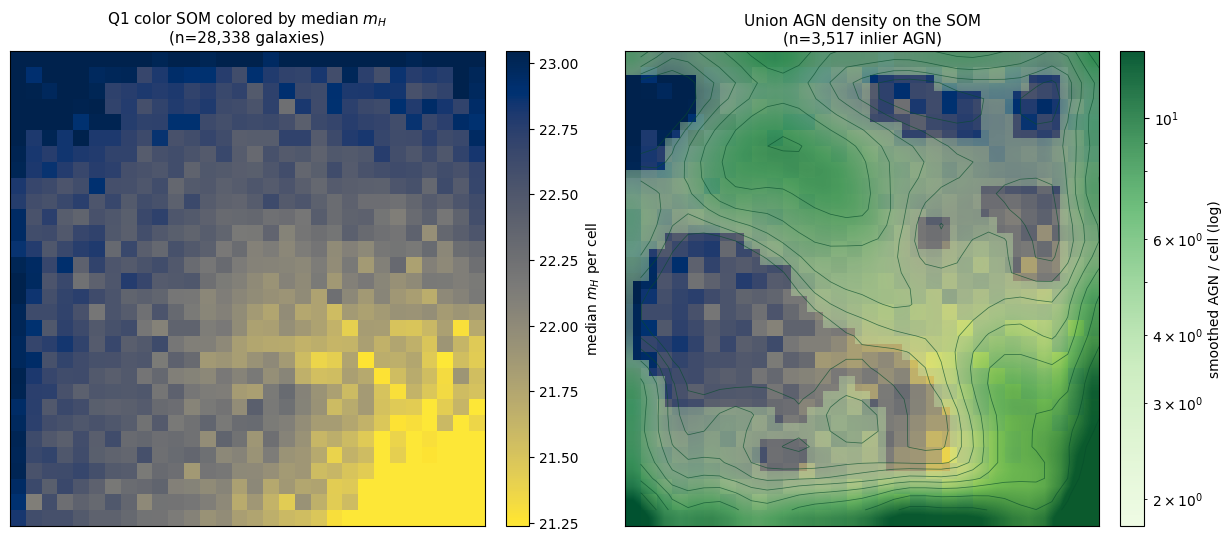

In [3]:
# Median observed-frame mH per cell (the manifold's brightness background).
med_mH = median_map(train['mH_obs'], bmu_train, msz=MSZ)
mH_bg = fill_nan_nearest(med_mH)
mH_lo, mH_hi = np.nanpercentile(med_mH, [5, 95])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))
for ax in axes:
    im_bg = ax.imshow(mH_bg, origin='lower', cmap='cividis_r', vmin=mH_lo, vmax=mH_hi)
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im_bg, ax=axes[0], fraction=0.046, pad=0.04).set_label('median $m_H$ per cell', fontsize=10)
axes[0].set_title(f'Q1 color SOM colored by median $m_H$\n(n={len(train):,} galaxies)', fontsize=11)

# Right panel: union AGN density overlay.
H_union = bmu_density(bmu_in)
im_d, vlo, vhi = overlay(axes[1], H_union)
if im_d is not None:
    fig.colorbar(im_d, ax=axes[1], fraction=0.046, pad=0.04).set_label('smoothed AGN / cell (log)', fontsize=10)
axes[1].set_title(f'Union AGN density on the SOM\n(n={len(agn_in):,} inlier AGN)', fontsize=11)
plt.tight_layout(); plt.show()


## Task 1 - Where does *your* selection method live? (~10 min)

The union map above mixes every AGN selection technique into one footprint.
Different methods sample different physics: WISE colors trace hot dust,
Euclid NIR colors trace mid-IR-like features in extended bandpasses, Gaia DR3
selects bright quasars by parallax/photometry, etc. On a common manifold we
can ask: *do these methods land in the same place, or different ones?*

Available flags in this EDF-N sample (each is a 0/1 column on `agn_in`):

| Flag column | What it selects |
| --- | --- |
| `R90_agn_candidate` | WISE mid-IR color, 90% reliability (Assef+18) |
| `C75_agn_candidate` | WISE mid-IR color, 75% completeness (Assef+18) |
| `JH_IeY_qso_candidate` | Euclid NIR two-color box (Bisigello+24) |
| `IeH_gz_qso_candidate` | Euclid + optical color box (Bisigello+24) |
| `B24a_qso_candidate` | Optical + NIR color cut (Bisigello+24 a) |
| `B24b_qso_candidate` | Optical + NIR color cut (Bisigello+24 b) |
| `GDR3_qso_candidate` | Gaia DR3 quasar candidate |
| `PRF_qso_candidate` | Probabilistic Random Forest |
| `AGN_sed_candidate` | SED-template based (EDF-N only) |
| `DESI_broadline_qso_candidate` | DESI spec-confirmed broad-line QSO |
| `DESI_niibpt_agn_candidate` | DESI [NII]/H$\alpha$ BPT AGN |

**Your task:** pick *one* flag in the cell below. The cell will plot two panels:
left = where that method's AGN sit on the SOM; right = where they are *enriched*
relative to the union AGN distribution (green = preferred regions for that method).

Compare with your neighbor: did you pick the same place on the manifold?


AGN flagged by R90_agn_candidate: 123 (out of 3,517 inliers)


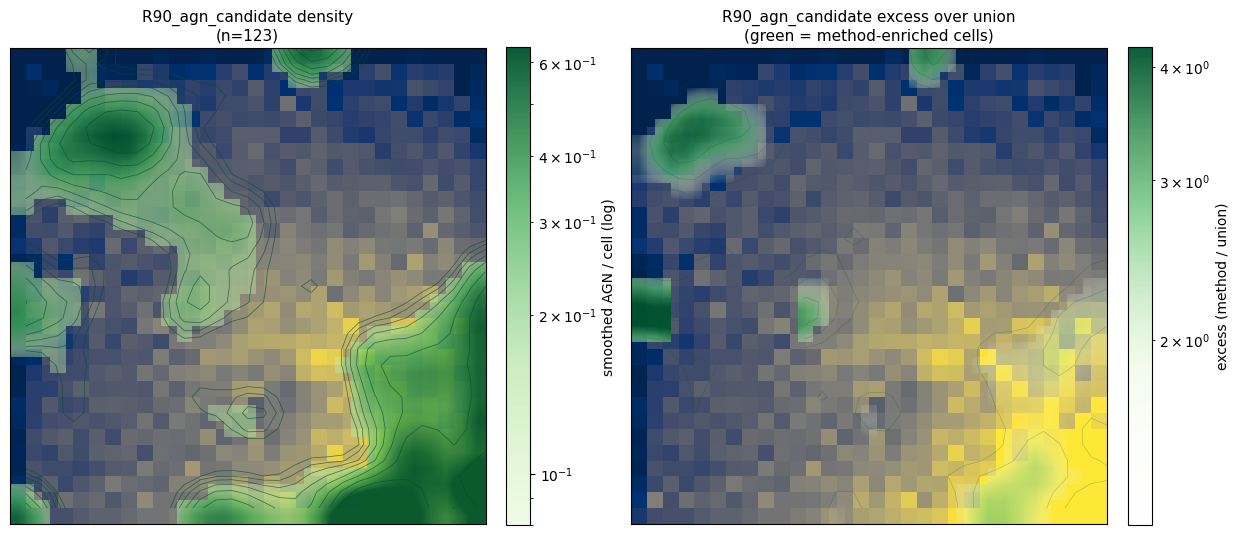

In [4]:
# === TODO 1: pick one flag column from the table above ====================
method = 'R90_agn_candidate'      # <-- change this to any flag column name
# ==========================================================================

assert method in agn_in.colnames, f'{method!r} is not a column in agn_in.'
method_mask = np.asarray(agn_in[method] == 1)
n_method = int(method_mask.sum())
print(f'AGN flagged by {method}: {n_method:,} (out of {len(agn_in):,} inliers)')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))
for ax in axes:
    ax.imshow(mH_bg, origin='lower', cmap='cividis_r', vmin=mH_lo, vmax=mH_hi)
    ax.set_xticks([]); ax.set_yticks([])

# Left: BMUs and smoothed density of the selected method.
H_method = bmu_density(bmu_in[method_mask]) if n_method else None
if H_method is not None:
    im_d, _, _ = overlay(axes[0], H_method)
    if im_d is not None:
        fig.colorbar(im_d, ax=axes[0], fraction=0.046, pad=0.04).set_label('smoothed AGN / cell (log)', fontsize=10)
if 0 < n_method <= 60:
    x_pt, y_pt = jitter_bmu(bmu_in[method_mask], seed=42)
    axes[0].scatter(x_pt, y_pt, marker='x', s=30, linewidths=0.9,
                    color='white', alpha=0.9, zorder=5)
    axes[0].scatter(x_pt, y_pt, marker='x', s=30, linewidths=0.55,
                    color=AGN_OVERLAY_COLOR, alpha=0.9, zorder=6)
axes[0].set_title(f'{method} density\n(n={n_method:,})', fontsize=11)

# Right: method-excess over the union distribution.
im_x = overlay_method_excess(axes[1], H_method, H_union)
if im_x is not None:
    fig.colorbar(im_x, ax=axes[1], fraction=0.046, pad=0.04).set_label('excess (method / union)', fontsize=10)
axes[1].set_title(f'{method} excess over union\n(green = method-enriched cells)', fontsize=11)
plt.tight_layout(); plt.show()


**Discussion prompt.** Where on the SOM did your method land? Bright-host cells (light)
or faint-host cells (dark)? Is the enrichment spread out across the manifold or
concentrated in one corner? Compare with someone who picked a different flag - the
*excess* maps usually disagree, even when the *density* maps look similar.


## Task 2 - Project a candidate, then verify it with three live cloud reads (~15 min)

We pre-selected three AGN candidates that each land in a distinct SOM neighborhood
and are selected by a different combination of methods. Pick one, project it onto
the SOM, then pull three independent measurements **live from IRSA** to check
whether the colors-and-manifold prediction agrees with the actual photons:

- **2b** SIR 1D spectrum - direct S3 FITS read from `s3://nasa-irsa-euclid-q1/...`
- **2c** MER multi-band imaging - server-side cutout from IRSA IBE
- **2d** SPE H$\alpha$ line measurement - one-row TAP query against the SPE line catalog


In [5]:
# Pre-picked candidates, with the flags that selected them and their SOM cell.
for i, p in enumerate(picks):
    flags_short = ', '.join(p['flags_set'][:4])
    if len(p['flags_set']) > 4:
        flags_short += f' ... (+{len(p["flags_set"]) - 4} more)'
    print(f'[{i}] object_id = {p["object_id_euclid"]}')
    print(f'    RA, Dec   = {p["ra"]:.5f}, {p["dec"]:.5f}')
    print(f'    z = {p["z_final"]:.3f}  ({p["z_source"]})')
    print(f'    SOM cell  = ({p["bmu_row"]}, {p["bmu_col"]})')
    print(f'    flagged by: {flags_short}')
    print()


[0] object_id = 2657969414657962795
    RA, Dec   = 265.79694, 65.79628
    z = 1.674  (spec)
    SOM cell  = (29, 18)
    flagged by: B24a_qso_candidate, C75_agn_candidate, GDR3_qso_candidate, JH_IeY_qso_candidate ... (+5 more)

[1] object_id = 2658828502651143856
    RA, Dec   = 265.88285, 65.11439
    z = 1.711  (spec)
    SOM cell  = (17, 12)
    flagged by: JH_IeY_qso_candidate, IeH_gz_qso_candidate, B24b_qso_candidate, DESI_qso_candidate

[2] object_id = 2658839442660009656
    RA, Dec   = 265.88394, 66.00097
    z = 1.527  (spec)
    SOM cell  = (11, 22)
    flagged by: PRF_qso_candidate, AGN_sed_candidate



In [6]:
# === TODO 2: pick a candidate =============================================
# Recommended first pass: one of the three curated picks above. Each has a
# Q1 SIR spectrum, spec-z, and a distinct SOM neighborhood.
my_id = picks[0]['object_id_euclid']     # also try picks[1] or picks[2]

# Or pick any AGN from the inlier sample. SIR coverage in EDF-N is very
# high (essentially every inlier AGN has a spectrum), but the cells below
# handle the missing case gracefully if you happen to hit one. Uncomment:
#   my_id = int(agn_in['object_id_euclid'][0])              # first inlier
#   my_id = int(agn_in[agn_in['z_source']=='spec']['object_id_euclid'][0])  # first spec-z
# ==========================================================================

row = agn[agn['object_id_euclid'] == my_id][0]
ra, dec = float(row['ra_euclid']), float(row['dec_euclid'])
z = float(row['z_final'])
print(f'Chose object_id {my_id}')
print(f'  RA, Dec = {ra:.6f}, {dec:.6f}')
print(f'  z = {z:.3f} ({row["z_source"]})')


Chose object_id 2657969414657962795
  RA, Dec = 265.796941, 65.796280
  z = 1.674 (spec)


### 2a. Project the candidate onto the SOM (local compute)

To project a source onto the SOM you need its six adjacent colors normalized the
same way as the training sample (z-score with the training `mu`, `sigma`), then
the SOM's `winner()` method returns the best-matching unit (BMU). This step is
pure local arithmetic - no cloud reads.


Colors: {'gr': np.float64(0.126), 'ri': np.float64(0.147), 'iz': np.float64(0.123), 'zy': np.float64(0.029), 'yj': np.float64(0.025), 'jh': np.float64(0.274)}
Projected BMU: (np.int64(29), np.int64(18))  (cached value was (29, 18))


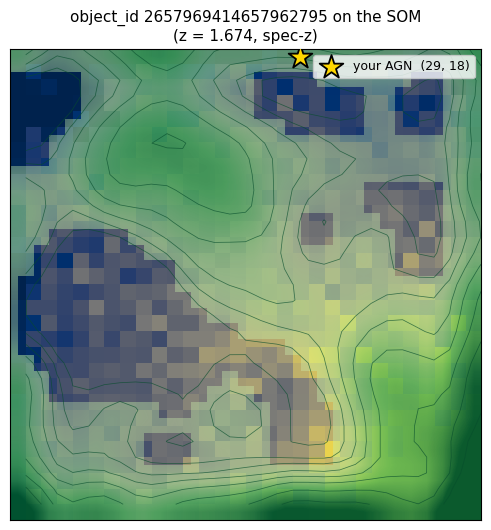

In [7]:
# === TODO 3: normalize the candidate's colors and find its BMU ============
colors = np.array([row[c] for c in COLOR_NAMES])   # six adjacent colors (mag)
print('Colors:', dict(zip(COLOR_NAMES, np.round(colors, 3))))

v_norm = (colors - mu) / sigma                      # z-score with training stats
bmu = som.winner(v_norm)                            # (row, col) on the SOM grid
# ==========================================================================
print(f'Projected BMU: {bmu}  (cached value was ({int(row["bmu_row"])}, {int(row["bmu_col"])}))')

# Plot the BMU on top of the union AGN density background.
fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.imshow(mH_bg, origin='lower', cmap='cividis_r', vmin=mH_lo, vmax=mH_hi)
if H_union is not None:
    overlay(ax, H_union)
ax.scatter(bmu[1], bmu[0], marker='*', s=320, edgecolors='black', linewidths=1.3,
           facecolor='gold', zorder=10, label=f'your AGN  ({bmu[0]}, {bmu[1]})')
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc='upper right', frameon=True, fontsize=9)
ax.set_title(f'object_id {my_id} on the SOM\n(z = {z:.3f}, {row["z_source"]}-z)', fontsize=11)
plt.tight_layout(); plt.show()


### 2b. Pull the SIR spectrum live from S3

Two cloud calls happen here. First, a TAP query against IRSA's spectrum-association
table to find which FITS file in the public bucket contains this object's spectrum
(a sub-second SQL lookup). Second, an `astropy.io.fits.open(s3_uri, ...)` against
`s3://nasa-irsa-euclid-q1/...` with `fsspec` - that's a **direct anonymous S3 read**
of the FITS file, no download.


In [8]:
# Step 1: TAP query for the spectrum-file association.
adql_assoc = (
    'SELECT objectid, path, hdu '
    f'FROM {SPECTRA_ASSOC_TABLE} '
    f'WHERE objectid = {my_id}'
)
print('TAP query:')
print(adql_assoc)
assoc = Irsa.query_tap(adql_assoc).to_table()
print(f'Returned {len(assoc)} row(s).')

have_spectrum = len(assoc) > 0
if not have_spectrum:
    print('  -- no Q1 SIR spectrum recorded for this object_id.')
    print('     Imaging (2c) still works; pick a different object_id if you')
    print('     want to see a spectrum here.')
else:
    for r in assoc:
        print(f'  hdu={int(r["hdu"]):>3d}  path={r["path"]}')
    # Step 2: build the S3 URI for the spectrum FITS and open it directly.
    from agn_tutorial_utils import association_to_s3_uri
    first = assoc[0]
    s3_uri = association_to_s3_uri(first['path'])
    print(f'\nReading from: {s3_uri}')
    print(f'  HDU index in that file: {int(first["hdu"])}')


TAP query:
SELECT objectid, path, hdu FROM euclid.objectid_spectrafile_association_q1 WHERE objectid = 2657969414657962795
Returned 1 row(s).
  hdu=9225  path=api/spectrumdm/convert/euclid/q1/SIR/102159188/EUC_SIR_W-COMBSPEC_102159188_2024-11-05T15:41:18.850898Z.fits?dataset_id=euclid_combspec&hdu=9225

Reading from: s3://nasa-irsa-euclid-q1/q1/SIR/102159188/EUC_SIR_W-COMBSPEC_102159188_2024-11-05T15:41:18.850898Z.fits
  HDU index in that file: 9225


wavelength samples: 468
observed range:     12490 Angstrom - 18747 Angstrom


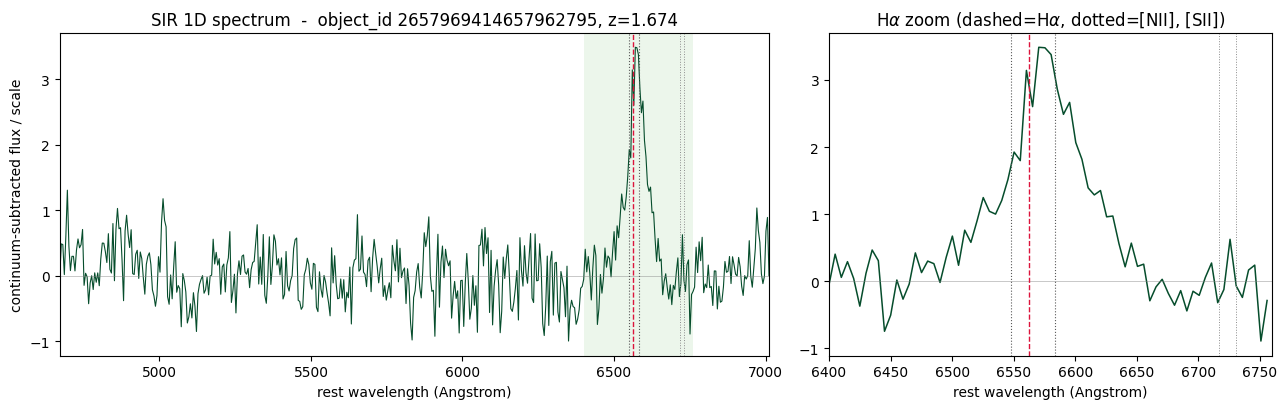

In [9]:
# Skip cleanly if the source has no SIR association; otherwise read the FITS
# from S3 and plot. The helper does the same fits.open(s3_uri, fsspec_kwargs=...)
# under the hood, with a local .npz cache for repeat calls on the same id.
if not have_spectrum:
    print('No SIR spectrum to read. Move on to cell 2c (imaging).')
else:
    one_row = agn[agn['object_id_euclid'] == my_id]
    spectra = get_Q1_sir_spectra(one_row, n=1, cache_check=True)
    if my_id not in spectra:
        print('Association returned a row but the FITS HDU was unreadable. Skipping.')
    else:
        spec = spectra[my_id]
        print(f'wavelength samples: {len(spec["wave"]):,}')
        print(f'observed range:     {spec["wave"][0]:.0f} - {spec["wave"][-1]:.0f}')

        rest, y = continuum_normalized_rest_spectrum(spec, z)
        fig, (axw, axz) = plt.subplots(1, 2, figsize=(13.0, 4.2),
                                        gridspec_kw={'width_ratios': [1.6, 1.0]})
        axw.plot(rest, y, color='#064d2c', lw=0.8)
        axw.axhline(0, color='0.5', lw=0.6, alpha=0.5)
        axw.axvspan(6400, 6760, color='#82c77a', alpha=0.15, lw=0)
        mark_halpha_complex(axw, full_range=True)
        axw.set_xlim(np.nanmin(rest), np.nanmax(rest))
        axw.set_xlabel('rest wavelength (Angstrom)')
        axw.set_ylabel('continuum-subtracted flux / scale')
        axw.set_title(f'SIR 1D spectrum  -  object_id {my_id}, z={z:.3f}')
        zoom = (rest > 6400) & (rest < 6760)
        axz.plot(rest[zoom], y[zoom], color='#064d2c', lw=1.1)
        axz.axhline(0, color='0.5', lw=0.6, alpha=0.5)
        mark_halpha_complex(axz, full_range=True)
        axz.set_xlim(6400, 6760)
        axz.set_xlabel('rest wavelength (Angstrom)')
        axz.set_title(r'H$\alpha$ zoom (dashed=H$\alpha$, dotted=[NII], [SII])')
        plt.tight_layout(); plt.show()


### 2c. Pull multi-band MER imaging cutouts live from IRSA IBE

Now an imaging look at the same source. We use IRSA's IBE cutout service:
an SIA query returns the URL of the full MER mosaic FITS that covers our position;
we append `?center=ra,dec&size=Xarcsec` to ask the server to return only the
small region we want. The server-side cutout comes back as a ~40 KB gzipped FITS
in a fraction of a second - no need to stream the full 1.4 GB mosaic.

Below we fetch VIS (high-resolution optical) and three NISP NIR bands (Y, J, H).


In [10]:
# Fetch four bands - the helper prints each cutout URL so you can see the cloud calls.
from agn_tutorial_utils import _mer_sia_lookup
import time

t0 = time.time()
sia_rows = _mer_sia_lookup(ra, dec)
print(f'SIA query: {time.time()-t0:.2f} s, {len(sia_rows)} mosaic rows at this position')
print('IBE cutout URLs being fetched:')

BANDS = ['VIS', 'Y', 'J', 'H']
cutouts = {}
t0 = time.time()
for b in BANDS:
    cutouts[b] = get_Q1_mer_cutout(ra, dec, band=b, size_arcsec=8.0, sia_rows=sia_rows, verbose=True)
print(f'Fetched {len(BANDS)} cutouts in {time.time()-t0:.2f} s')

# Print one S3 URI to make the cloud location explicit.
print(f'\n(For reference, the underlying S3 path of the VIS mosaic was:')
print(f' {cutouts["VIS"]["s3_uri"]})')


SIA query: 0.96 s, 49 mosaic rows at this position
IBE cutout URLs being fetched:
  band VIS: https://irsa.ipac.caltech.edu/ibe/data/euclid/q1/MER/102159188/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102159188-423E05_20241025T021839.326970Z_00.00.fits?center=265.796941,65.796280&size=8.00arcsec
  band Y: https://irsa.ipac.caltech.edu/ibe/data/euclid/q1/MER/102159188/NISP/EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102159188-BEDF51_20241024T200922.179207Z_00.00.fits?center=265.796941,65.796280&size=8.00arcsec
  band J: https://irsa.ipac.caltech.edu/ibe/data/euclid/q1/MER/102159188/NISP/EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102159188-6A37E3_20241024T201312.012919Z_00.00.fits?center=265.796941,65.796280&size=8.00arcsec
  band H: https://irsa.ipac.caltech.edu/ibe/data/euclid/q1/MER/102159188/NISP/EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102159188-FB44BF_20241024T202039.599711Z_00.00.fits?center=265.796941,65.796280&size=8.00arcsec
Fetched 4 cutouts in 0.01 s

(For reference, the underlying S3 path of the VIS mosaic was:
 s3://na

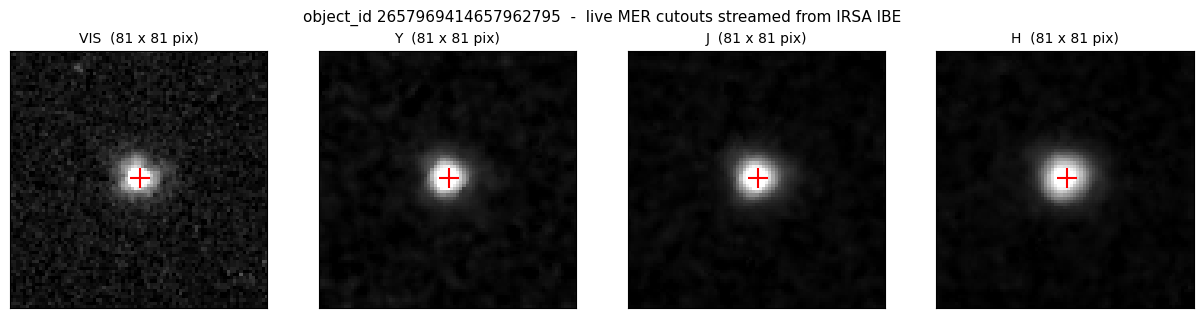

In [11]:
# Display the four bands side-by-side with consistent arcsinh stretch per panel.
from matplotlib.colors import AsinhNorm

fig, axes = plt.subplots(1, len(BANDS), figsize=(3.0 * len(BANDS) + 0.5, 3.2))
for ax, b in zip(axes, BANDS):
    data = cutouts[b]['data']
    vmin = float(np.nanpercentile(data, 5))
    vmax = float(np.nanpercentile(data, 99.5))
    span = max(vmax - vmin, 1e-6)
    ax.imshow(data, origin='lower', cmap='gray',
              norm=AsinhNorm(linear_width=0.1 * span, vmin=vmin, vmax=vmax))
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{b}  ({data.shape[1]} x {data.shape[0]} pix)', fontsize=10)
    # Center crosshair on source position.
    yc, xc = data.shape[0] / 2, data.shape[1] / 2
    ax.plot(xc, yc, marker='+', color='red', markersize=14, markeredgewidth=1.5)
fig.suptitle(f'object_id {my_id}  -  live MER cutouts streamed from IRSA IBE', fontsize=11)
plt.tight_layout(); plt.show()


### 2d. Look up the catalog SPE H$\alpha$ measurement (live TAP)

Finally a quick cross-check against Euclid's own automated line-feature catalog.
SPE measures Gaussian fits to spectral lines and stores flux, EW, and S/N per line.
We run a one-row ADQL query for this object's H$\alpha$ row(s) and compare with
what we just saw in the 1D spectrum.


In [12]:
# === Live TAP query - the SPE line-feature catalog is not pre-cached =====
adql_spe = (
    'SELECT spe_rank, spe_line_central_wl_gf, spe_line_flux_gf, '
    'spe_line_flux_err_gf, spe_line_snr_gf, spe_line_ew_gf '
    f'FROM {SPE_LINES_TABLE} '
    f'WHERE object_id = {my_id} '
    "AND spe_line_name = 'Halpha'"
)
print('Live TAP query:')
print(adql_spe)

result = Irsa.query_tap(adql_spe).to_table()
print(f'\nReturned {len(result)} row(s):')
if len(result) == 0:
    print('  (no Halpha measurement in the SPE catalog for this source.)')
else:
    result.pprint(max_lines=10, max_width=120)
    print()
    best = result[np.argmax(np.asarray(result['spe_line_snr_gf'], dtype=float))]
    print(f'Best-S/N row:  central wavelength = {float(best["spe_line_central_wl_gf"]):.1f} Angstrom (observed)')
    print(f'               flux  = {float(best["spe_line_flux_gf"]):.3e} erg/s/cm2')
    print(f'               S/N   = {float(best["spe_line_snr_gf"]):.2f}')
    print(f'               |EW|  = {abs(float(best["spe_line_ew_gf"])):.1f} Angstrom')
    print(f'Predicted Halpha at z={z:.3f}: observed wavelength = '
          f'{6562.8 * (1+z):.1f} Angstrom (rest 6562.8 A)')


Live TAP query:
SELECT spe_rank, spe_line_central_wl_gf, spe_line_flux_gf, spe_line_flux_err_gf, spe_line_snr_gf, spe_line_ew_gf FROM euclid_q1_spe_lines_line_features WHERE object_id = 2657969414657962795 AND spe_line_name = 'Halpha'

Returned 5 row(s):
spe_rank spe_line_central_wl_gf spe_line_flux_gf spe_line_flux_err_gf spe_line_snr_gf spe_line_ew_gf
-------- ---------------------- ---------------- -------------------- --------------- --------------
       0             17592.3418  1.046400574e-15      2.240838791e-15               0   -142.3322296
       1                    -99              -99                  -99             -99            -99
       2                    -99              -99                  -99             -99            -99
       3                    -99              -99                  -99             -99            -99
       4                    -99              -99                  -99             -99            -99

Best-S/N row:  central wavelength = 1

**Three independent cloud reads, one consistent answer.** The 1D spectrum shows the
line, the imaging shows the host, and the SPE catalog quantifies the line - all
fetched live from `irsa.ipac.caltech.edu` or `nasa-irsa-euclid-q1` in this notebook,
with no preloaded data products beyond the SOM artifacts.

Try changing `my_id` to one of the other curated picks, or to any `object_id_euclid`
from `agn_in`, and rerunning Task 2. Different SOM neighborhoods often correspond to
different AGN flavors - compact point source vs extended host, broad-line vs narrow,
bright vs faint - which you can read off directly from the imaging cell.


## Wrap-up

In ~30 minutes you have:

1. Loaded a pre-trained Q1 color SOM and an EDF-N AGN catalog projected onto it.
2. Picked one AGN selection method and visualized where it is enriched on the manifold.
3. Picked an individual candidate and verified it with **three independent live cloud reads**:
   - a 1D SIR spectrum read directly from `s3://nasa-irsa-euclid-q1/...`,
   - multi-band MER imaging cutouts streamed from IRSA's IBE server-side cutout service,
   - a one-row SPE H$\alpha$ measurement from a live TAP query.

**The cloud point.** None of those data products were downloaded in advance. The
same code, run from a Fornax JupyterLab session in the same AWS region, would
complete in a fraction of the time you saw here (the SIA + IBE round-trips dominate
from a laptop). It scales unchanged to the full Q1 release (~30M sources, ~150 deg2)
and onward to DR1 with no rewrite.

**Where to go next.**

- Full pipeline (queries, training, all 3 fields, north/south overlays, SPE H$\alpha$
  diagnostics): [`Euclid_AGN_Tutorial.ipynb`](Euclid_AGN_Tutorial.ipynb).
- IRSA's reference Euclid Q1 cloud-access tutorial:
  https://caltech-ipac.github.io/irsa-tutorials/euclid-cloud-access/
- Cluster-finding example: [IRSA Euclid clusters tutorial](https://caltech-ipac.github.io/irsa-tutorials/euclid-clusters-tutorial/).
- SPE line-feature catalog: [IRSA Euclid SPE catalog tutorial](https://caltech-ipac.github.io/irsa-tutorials/euclid-intro-spe-catalog/).

**Acknowledgments.** AGN candidate catalogs from Euclid Collaboration: Matamoro Zatarain
et al. (2025); Q1 data products distributed by NASA/IPAC IRSA. The SOM methodology
extends Sanjaripour et al. (2024) and a companion Euclid Q1 paper (in prep).
